# Simple Portfolio Construction

`Signals.ipynb` originally bought the single exchange-traded fund (ETF) with the highest predicted return. `Allocation.ipynb` then showed that searching over many allocation rules was unstable, but that partial allocation often helped.

This notebook makes the smallest useful change: **hold the two ETFs with the highest predicted returns, at 50% each**. It reuses the existing walk-forward predictions, rebalance dates, transaction-cost model, and backtest functions. It does not fit another model, tune another parameter, or introduce an optimizer.

> Research status: this is a simple construction example, not a new untouched out-of-sample test. The top-two rule was chosen after reading the results already reported in `Allocation.ipynb`. It also inherits that notebook's documented feature-selection and same-date timestamp limitations.

## 1. Reuse the current research pipeline

The captured run keeps this notebook short while making it reproducible from a fresh kernel. All underlying feature engineering, Ridge models, walk-forward predictions, return alignment, and cost accounting remain defined in `Allocation.ipynb`.

In [1]:
%%capture allocation_run
%run Allocation.ipynb

## 2. Convert predictions into portfolio weights

Let $\hat{r}_{i,t}$ be the predicted return for ETF $i$ at rebalance date $t$. Let $\operatorname{rank}_{i,t}=1$ denote the highest prediction. With $K=2$ selected ETFs, the portfolio weight is

$$
w_{i,t}=
\begin{cases}
1/K, & \operatorname{rank}_{i,t}\le K,\\
0, & \operatorname{rank}_{i,t}>K.
\end{cases}
$$

Here, $w_{i,t}$ is the fraction of portfolio net asset value invested in ETF $i$. Therefore the two selected ETFs each receive 50%, weights are non-negative, and the weights sum to 100% on every rebalance date.

In [2]:
PORTFOLIO_SIZE = 2
TOP_TWO_CONFIG = {
    "scheme": "top_k",
    "transform": "demean",
    "k": PORTFOLIO_SIZE,
}

# Use the same untouched allocation holdout dates as the existing comparison.
top_two_weights = build_weights(TOP_TWO_CONFIG, holdout_dates)

# Construction invariants: long-only, fully invested, and exactly two holdings.
assert (top_two_weights >= 0.0).all().all()
assert np.allclose(top_two_weights.sum(axis=1), 1.0)
assert (top_two_weights.gt(0.0).sum(axis=1) == PORTFOLIO_SIZE).all()

print("Mean portfolio weights over the evaluation period:")
display(top_two_weights.mean().rename("mean_weight").to_frame().round(3))
print("First five rebalances:")
display(top_two_weights.head())

Mean portfolio weights over the evaluation period:


,mean_weight
SPY,0.452
EZU,0.194
EWJ,0.355


First five rebalances:


,SPY,EZU,EWJ
Dates,,,
2021-10-14,0.5,0.0,0.5
2021-11-11,0.5,0.0,0.5
2021-12-09,0.5,0.0,0.5
2022-01-06,0.5,0.5,0.0
2022-02-03,0.5,0.0,0.5


## 3. Compare with the existing alternatives

Returns below are net of the same 5-basis-point per-side trading cost used in `Allocation.ipynb`. One basis point is 0.01 percentage point. The comparison changes only the portfolio-construction rule; the predictions and evaluation dates are identical.

In [3]:
_, top_two_backtest, top_two_stats = evaluate(
    TOP_TWO_CONFIG,
    holdout_dates,
)

comparison = pd.concat(
    [
        top_two_stats.rename("top_two_50_50").to_frame().T,
        holdout_performance.loc[
            ["single_asset_rotation", "equal_weight", "SPY_only"]
        ],
    ]
)

comparison[
    [
        "ann_return",
        "ann_vol",
        "sharpe",
        "max_drawdown",
        "ann_turnover",
        "cost_drag",
    ]
].round(4)

,ann_return,ann_vol,sharpe,max_drawdown,ann_turnover,cost_drag
top_two_50_50,0.1228,0.1500,0.8189,-0.2262,4.4031,0.0022
single_asset_rotation,0.1183,0.1559,0.7589,-0.1960,6.3000,0.0032
equal_weight,0.1074,0.1493,0.7191,-0.2667,0.3836,0.0002
SPY_only,0.1280,0.1474,0.8679,-0.2089,0.2032,0.0001


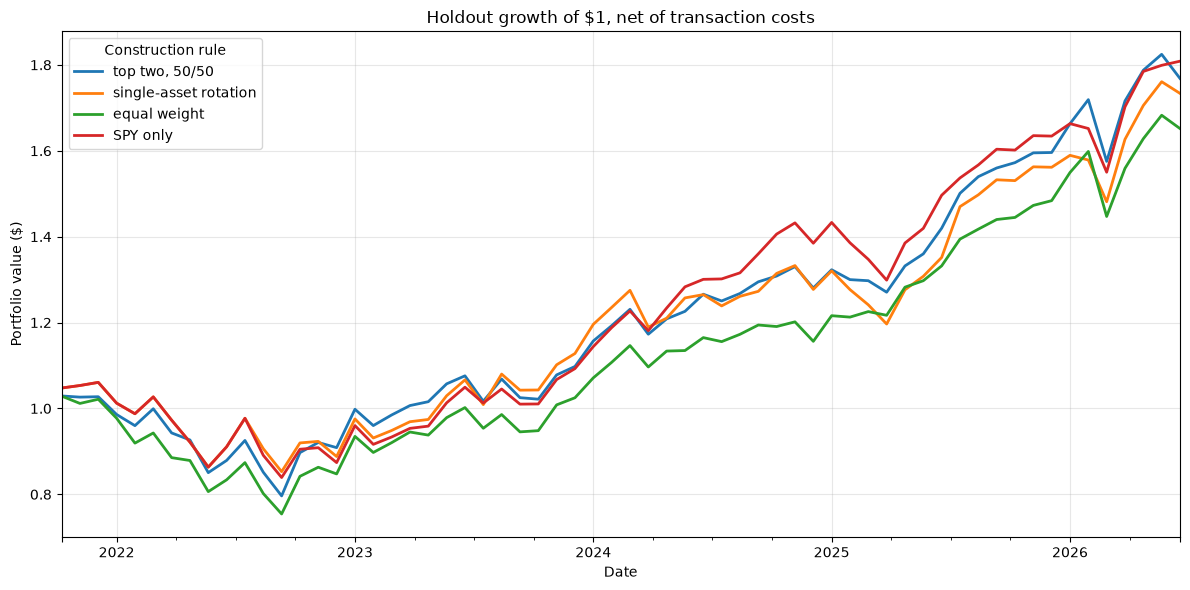

In [4]:
returns_to_plot = pd.DataFrame(
    {
        "top two, 50/50": top_two_backtest["net"],
        "single-asset rotation": holdout_bt["single_asset_rotation"]["net"],
        "equal weight": holdout_bt["equal_weight"]["net"],
        "SPY only": holdout_bt["SPY_only"]["net"],
    }
)

growth = (1.0 + returns_to_plot).cumprod()
ax = growth.plot(figsize=(12, 6), linewidth=2.0)
ax.set_title("Holdout growth of $1, net of transaction costs")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio value ($)")
ax.grid(True, alpha=0.3)
ax.legend(title="Construction rule")
plt.tight_layout()
plt.show()

## Takeaway

The portfolio now expresses relative confidence without making an all-or-nothing bet: the two strongest predicted ETFs are held equally, and the weakest is excluded. This is deliberately a fixed rule because the existing allocation study found that its tuning-period rankings reversed on the holdout.

The reported performance must still be interpreted as **exploratory**. Choosing this rule after inspecting `Allocation.ipynb` means the same history helped motivate the rule. A genuinely new out-of-sample period is needed before treating any improvement as evidence that the construction will generalize.